# MNIST - Handwritten Digit Classification

In [2]:
import tensorflow as tf

In [4]:
from tensorflow.keras.datasets import mnist

In [5]:
(train_images , train_labels) , (test_images , test_labels)  = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
type(train_images), train_images.ndim

(numpy.ndarray, 3)

In [7]:
train_images.shape

(60000, 28, 28)

In [8]:
train_labels[59999]

np.uint8(5)

In [9]:
train_images[59999]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

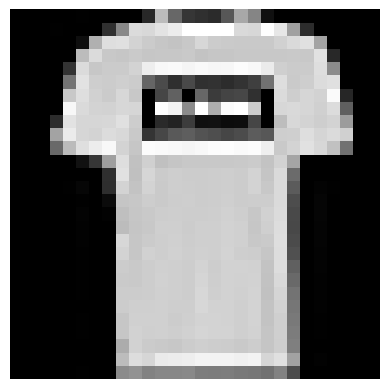

In [12]:
import matplotlib.pyplot as plt

plt.imshow(train_images[1], cmap="gray")
plt.axis("off")
plt.show()

In [13]:
train_images[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [14]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

In [15]:
from tensorflow.keras.utils import to_categorical

In [16]:
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)

# Stage 4: Model Banana (Building the Neural Network)

In [17]:
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

Sequential ek Keras class hai jisse aap model ko layers ka ek simple stack bana sakte ho, ek ke baad ek — data pehli layer se seedha aakhri layer tak jaata hai.

Dense(512, activation="relu")

Dense ka matlab "fully connected" layer hai — har input is layer ke 512 "neurons" mein se har ek se connected hota hai (neuron ek chhota unit hota hai jo calculation karta hai). 512 iss layer ke neurons ki tadaad hai — zyada neurons = complex patterns seekhne ki zyada capacity (lekin zyada computation bhi).

activation="relu" calculation ke baad lagaya jaane wala function hai — ReLU kisi bhi negative number ko 0 bana deta hai aur positive numbers ko waise hi rehne deta hai. Agar activation function na ho, to layers ka stack karna mathematically bekaar hoga (multiple linear layers mil kar ek hi linear layer ban jaate hain) — activation functions network ko non-linear, complex patterns seekhne dete hain.

Dense(10, activation="softmax")

Ye output layer hai. Ismein 10 neurons hain — har digit (0–9) ke liye ek. softmax ek activation function hai jo raw outputs ko probabilities mein convert karta hai jo mil kar 1 banti hain — to model batata hai "mujhe 95% yaqeen hai ye 3 hai, 3% yaqeen hai ye 8 hai," waghera.

In [23]:
model = Sequential([
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax") #This is the output layer.10 neurons — one for each possible digit (0–9).
])

# Stage 5: Compiling the Model

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

# model.compile(optimizer="adam",loss="categorical_crossentropy", metrics=["accuracy"])

optimizer="adam" — Adam is an algorithm that decides how the model's internal numbers (called "weights") get updated after each mistake, to gradually reduce errors. It's a popular, reliable default choice.

loss="sparse_categorical_crossentropy" — the "loss function" measures how wrong the model's prediction was compared to the true label. The model's whole goal during training is to make this loss number as small as possible.

metrics=["accuracy"] — this just tells Keras to also report accuracy (% correct) while training, purely for us to monitor — it doesn't affect learning itself.

# Stage 6: Data Prepare Karna (Reshaping & Normalizing)

In [20]:
train_images = train_images.reshape((60000, 784))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 784))
test_images = test_images.astype("float32") / 255

Humari Dense layers har image ke liye flat list of numbers expect karti hain, 2D grid nahi. Chunke har image 28×28 pixels ki hai, hum usay "flatten" kar ke ek single row bana dete hain jismein 28 × 28 = 784 numbers hote hain.

Pehle pixel values 0–255 ke integers hote hain. Hum unhe decimal numbers (float32) mein badalte hain aur 255 se divide karte hain, taake har pixel 0.0 se 1.0 ke beech aa jaye. Isay normalization kehte hain — neural networks tezi se aur zyada reliably seekhte hain jab input numbers chhote, consistent range mein hon, bajaye 0–255 jaisi bari values ke.

# Stage 7: Model Train Karna (Training)

In [32]:
model.fit(train_images, train_labels, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9618 - loss: 0.1002
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9636 - loss: 0.0948
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9652 - loss: 0.0898
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9661 - loss: 0.0872
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9658 - loss: 0.0897
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9667 - loss: 0.0858
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.0778
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9705 - loss: 0.0766
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9700 - loss: 0.0770
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9718 - loss: 0.0726
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9724 - loss: 0.0728
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

model.fit(...) — ye actual training step hai, jahan model baar baar data dekhta hai aur apne internal weights adjust karta hai taake mistakes kam hon.

epochs=20 — ek "epoch" ka matlab hai poore 60,000 training images se ek baar guzarna. Yahan model poora dataset 20 dafa dekhta hai.

batch_size=128 — har single image ke baad weights update karne (slow) ya sab 60,000 ek saath (bohot memory chahiye) ke bajaye, model chhoti groups ("batches") mein — 128 images ek waqt mein — dekh kar weights update karta hai.

# Stage 8: Model Evaluate Karna (Testing on Unseen Data)

In [31]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.8937 - loss: 0.4249


[0.4248597025871277, 0.8937000036239624]

This runs the model on the test set (data it never trained on) and reports [loss, accuracy]. 95.1% accuracy on unseen data is a good sign — the model generalized well, not just memorized.

# Stage 9: Model Save Karna (Saving)

architecture + learned weights

In [27]:
model.save('mnist_fashion_model.keras')

# Stage 10: Apni Images Par Predict Karna (Custom Image Prediction)

In [28]:
from PIL import Image
import numpy as np

def image_classifier(image_path):
    image = Image.open(image_path)          # Image file open karo
    image = image.convert('L')               # Grayscale mein badlo
    image = image.resize((28, 28))           # 28x28 mein resize karo — YE MISSING THA

    image_array = np.array(image).astype('float32') / 255   # Normalize karo
    image_array = image_array.reshape(1, 784)                # Flatten karo

    prediction = model.predict(image_array)   # Sirf 1 baar predict
    predicted_digit = np.argmax(prediction)

    return predicted_digit, prediction

In [29]:
import numpy as np

In [30]:
prediction = model.predict(test_images[0:1])

predicted_label = np.argmax(prediction[0])

print("Predicted label:", predicted_label)
print("Actual label:", train_images[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted label: 9
Actual label: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        

Image.open(image) — PIL (Python Imaging Library, sometimes called Pillow) opens the image file.

.convert('L') — converts it to grayscale ("L" = "Luminance"), matching MNIST's format, since your model was trained on grayscale images.

np.array(image).astype('float')/255 — same normalization trick as before: convert pixels into a 0.0–1.0 range.

.reshape(1,784) — flatten into 784 numbers, and wrap it in an extra dimension (1, 784 instead of just 784) because Keras models expect a batch of images, even if it's a batch of just 1.

np.argmax(...) — model.predict() returns 10 probabilities (one per digit); argmax finds the index of the highest value — that index IS the predicted digit, since your output neurons are ordered 0 through 9.

In [ ]:
image_classifier("/content/drive/MyDrive/SMIT/Deep Learning/01_MNIST/1.webp")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


(np.int64(7),
 array([[1.0157488e-21, 1.3511568e-22, 6.0742835e-19, 9.9500337e-25,
         0.0000000e+00, 4.4868201e-01, 2.4338194e-15, 5.5131805e-01,
         1.5753609e-28, 1.2871393e-31]], dtype=float32))